In [1]:
import urllib.request
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

data_dir = Path('data')
enron_file = data_dir / 'enron_spam_data.zip'

raw_email_data = pd.read_csv(enron_file, compression='zip')
df_email = pd.DataFrame({
    'text': raw_email_data['Subject'].fillna('') + ' ' + raw_email_data['Message'].fillna(''),
    'label': (raw_email_data['Spam/Ham'] == 'spam').astype(int)
})
df_email['text'] = df_email['text'].str.strip()
df_email = df_email[df_email['text'].str.len() > 0].drop_duplicates(subset='text')

X_train_email, _, y_train_email, _ = train_test_split(
    df_email['text'].values,
    df_email['label'].values,
    test_size=0.2,
    stratify=df_email['label'],
    random_state=42
)

enron_words = {'enron', 'vince', 'kaminski', 'ect', 'hou'}
custom_stop_words = list(ENGLISH_STOP_WORDS.union(enron_words))

email_model = Pipeline([
    ('vect', CountVectorizer(stop_words=custom_stop_words, min_df=3, max_df=0.9)),
    ('clf', MultinomialNB(alpha=1.0))
])

print("Training baseline model on Enron emails...")
email_model.fit(X_train_email, y_train_email)
print("Training completed.")

Training baseline model on Enron emails...
Training completed.


In [2]:
sms_url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df_sms = pd.read_csv(sms_url, sep='\t', header=None, names=['label', 'text'])

X_sms = df_sms['text'].values
y_sms = (df_sms['label'] == 'spam').astype(int).values

print(f"SMS dataset loaded successfully. Total messages: {len(X_sms)}")
print(f"Spam ratio in SMS dataset: {y_sms.mean():.4f}")

SMS dataset loaded successfully. Total messages: 5572
Spam ratio in SMS dataset: 0.1341


In [3]:
from sklearn.metrics import classification_report

print("Predicting SMS messages using the email-trained model...")
y_sms_pred = email_model.predict(X_sms)

print("\n" + "=" * 55)
print("Classification Report (Exercise 5: SMS Generalization)")
print("=" * 55)
print(classification_report(y_sms, y_sms_pred, target_names=['Ham', 'Spam'], digits=4))

Predicting SMS messages using the email-trained model...

Classification Report (Exercise 5: SMS Generalization)
              precision    recall  f1-score   support

         Ham     0.9523    0.3474    0.5090      4825
        Spam     0.1739    0.8876    0.2909       747

    accuracy                         0.4198      5572
   macro avg     0.5631    0.6175    0.3999      5572
weighted avg     0.8479    0.4198    0.4798      5572



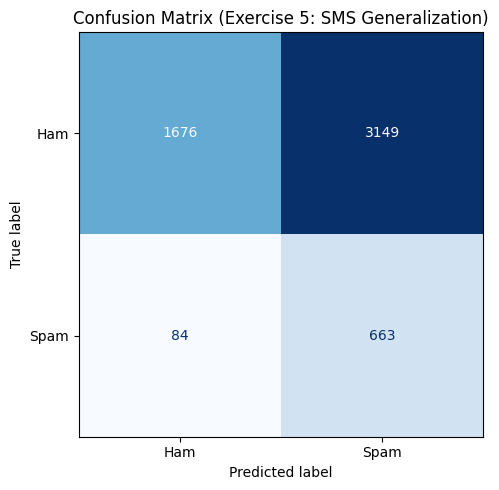

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_sms,
    y_sms_pred,
    display_labels=['Ham', 'Spam'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)
plt.title("Confusion Matrix (Exercise 5: SMS Generalization)")
plt.tight_layout()
plt.show()